# <font color=#0099CC>**Portfolio Backtest — Diagnostics & Setup**</font>

## <font color=#0099CC>**0. PURPOSE**</font>

This notebook verifies every building block before we run the actual backtest.
Run cells **one by one** — each prints diagnostics so you can catch issues early.

> Works on **Colab** and **local**. Paths are auto-detected.

---
## <font color=#0099CC>**1. ENVIRONMENT & PATHS**</font>

In [59]:
import shutil, importlib

# Clear the stale cache
cache_dir = os.path.join(BASE, '11_Portfolio', '__pycache__')
if os.path.isdir(cache_dir):
    shutil.rmtree(cache_dir)
    print(f'Deleted __pycache__')

# Force fresh import
import model_builder
importlib.reload(model_builder)
from model_builder import build_and_load_model
print(f'model_builder loaded: {model_builder.__file__}')

Deleted __pycache__
model_builder loaded: /content/drive/MyDrive/Taller4_DL_MIAX/11_Portfolio/model_builder.py


In [60]:
import sys, os

# Check if PORTFOLIO_DIR is in sys.path
portfolio_dir = os.path.join(BASE, '11_Portfolio')
print(f'PORTFOLIO_DIR: {portfolio_dir}')
print(f'In sys.path: {portfolio_dir in sys.path}')

# List files in 11_Portfolio
print(f'\nFiles in 11_Portfolio:')
for f in sorted(os.listdir(portfolio_dir)):
    print(f'  {f}')

# Check specifically for model_builder.py
mb_path = os.path.join(portfolio_dir, 'model_builder.py')
print(f'\nmodel_builder.py exists: {os.path.isfile(mb_path)}')

# Show full sys.path
print(f'\nFull sys.path:')
for p in sys.path:
    print(f'  {p}')

PORTFOLIO_DIR: /content/drive/MyDrive/Taller4_DL_MIAX/11_Portfolio
In sys.path: True

Files in 11_Portfolio:
  01_diagnostics.ipynb
  02_inference_colab.ipynb
  __pycache__
  config.py
  data_loader.py
  frac_diff_utils.py
  model_builder.py

model_builder.py exists: True

Full sys.path:
  /content/drive/MyDrive/Taller4_DL_MIAX/11_Portfolio
  /content/drive/MyDrive/Taller4_DL_MIAX/01_src_compartido
  /content
  /env/python
  /usr/lib/python312.zip
  /usr/lib/python3.12
  /usr/lib/python3.12/lib-dynload
  
  /usr/local/lib/python3.12/dist-packages
  /usr/lib/python3/dist-packages
  /usr/local/lib/python3.12/dist-packages/IPython/extensions
  /root/.ipython


In [61]:
import os, sys

def detect_env():
    try:
        import google.colab
        return 'colab'
    except ImportError:
        return 'local'

ENV = detect_env()

if ENV == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/Taller4_DL_MIAX'
else:
    BASE = os.path.abspath(os.path.join(os.getcwd(), '..'))

SRC = os.path.join(BASE, '01_src_compartido')
PORTFOLIO_DIR = os.path.join(BASE, '11_Portfolio')
for p in [SRC, PORTFOLIO_DIR]:
    if p not in sys.path:
        sys.path.insert(0, p)

print(f'> Entorno          : {ENV}')
print(f'> BASE             : {BASE}')
print(f'> SRC              : {SRC}')
print(f'> PORTFOLIO_DIR    : {PORTFOLIO_DIR}')
print(f'> SRC exists       : {os.path.isdir(SRC)}')
print(f'> PORTFOLIO exists : {os.path.isdir(PORTFOLIO_DIR)}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
> Entorno          : colab
> BASE             : /content/drive/MyDrive/Taller4_DL_MIAX
> SRC              : /content/drive/MyDrive/Taller4_DL_MIAX/01_src_compartido
> PORTFOLIO_DIR    : /content/drive/MyDrive/Taller4_DL_MIAX/11_Portfolio
> SRC exists       : True
> PORTFOLIO exists : True


---
## <font color=#0099CC>**2. CONFIGURATION & MODEL SELECTION**</font>

Change `ACTIVE_MODEL` to test a different model:
- `'inv_cnn'`   — Conv1D,   V_IN=10
- `'inv_mlp'`   — MLP,      V_IN=5
- `'inv_rnn'`   — LSTM,     V_IN=30
- `'inv_mixto'` — CNN+RNN+MLP, V_IN=90

In [62]:
# Force reload to pick up any file changes
import importlib
import config
importlib.reload(config)
from config import CFG, MODEL_CATALOG

# ╔══════════════════════════════════════════════════╗
# ║  CHANGE THIS TO SWITCH MODELS                   ║
# ╚══════════════════════════════════════════════════╝
ACTIVE_MODEL = 'inv_cnn'

CFG.apply_model(ACTIVE_MODEL)

# Override TICKERS with authoritative list from dataset_utils
try:
    from dataset_utils import TICKERS as TICKERS_TRAIN, D_FRAC_INV
    CFG.TICKERS = list(TICKERS_TRAIN)
    assert abs(D_FRAC_INV - CFG.D_FRAC) < 1e-9
    print(f'\u2713 TICKERS imported ({CFG.N_ASSETS} assets), D_FRAC_INV matches.')
except ImportError:
    print('Warning: dataset_utils not available. Using config defaults.')

print(f'\n-- Config summary --')
print(f'  Active model : {CFG.ACTIVE_MODEL}')
print(f'  Architecture : {CFG.ARCH}')
print(f'  V_IN / V_OUT : {CFG.V_IN} / {CFG.V_OUT}')
print(f'  D_FRAC       : {CFG.D_FRAC}')
print(f'  TOP_K        : {CFG.TOP_K}')
print(f'  REBAL_DAYS   : {CFG.REBAL_DAYS}')
print(f'  Period       : {CFG.BT_START} -> {CFG.BT_END}')
print(f'  Checkpoint   : {CFG.ckpt_path(BASE)}')

✓ TICKERS imported (23 assets), D_FRAC_INV matches.

-- Config summary --
  Active model : inv_cnn
  Architecture : cnn
  V_IN / V_OUT : 10 / 90
  D_FRAC       : 0.4
  TOP_K        : 5
  REBAL_DAYS   : 90
  Period       : 2025-01-01 -> 2025-12-31
  Checkpoint   : /content/drive/MyDrive/Taller4_DL_MIAX/08_results/checkpoints/inv_cnn_vin10_vout90_best.weights.h5


---
## <font color=#0099CC>**3. MODEL CHECKPOINT — existence & format**</font>

In [63]:
ckpt = CFG.ckpt_path(BASE)

if os.path.isfile(ckpt):
    size_mb = os.path.getsize(ckpt) / (1024 * 1024)
    print(f'\u2713 Checkpoint found: {os.path.basename(ckpt)}  ({size_mb:.2f} MB)')
else:
    print(f'\u2717 Checkpoint NOT found: {os.path.basename(ckpt)}')

# List all checkpoints
ckpt_dir = os.path.join(BASE, '08_results', 'checkpoints')
print(f'\n-- All checkpoints --')
if os.path.isdir(ckpt_dir):
    for f in sorted(os.listdir(ckpt_dir)):
        fpath = os.path.join(ckpt_dir, f)
        if os.path.isfile(fpath):
            size_mb = os.path.getsize(fpath) / (1024 * 1024)
            match = ' <<' if f == os.path.basename(ckpt) else ''
            print(f'  {f}  ({size_mb:.2f} MB){match}')

✓ Checkpoint found: inv_cnn_vin10_vout90_best.weights.h5  (0.49 MB)

-- All checkpoints --
  inv_cnn_vin10_vout90_best.weights.h5  (0.49 MB) <<
  inv_mlp_vin5_vout90_best.weights.h5  (0.78 MB)
  inv_rnn_vin30_vout90_best.weights.h5  (0.35 MB)


---
## <font color=#0099CC>**4. YFINANCE — price download**</font>

In [64]:
import data_loader
importlib.reload(data_loader)
from data_loader import download_prices, get_trading_dates, compute_rebalancing_dates, prepare_log_prices
import pandas as pd

dl_start = str(pd.Timestamp(CFG.BT_START) - pd.DateOffset(years=CFG.LOOKBACK_YEARS))
dl_end   = str(pd.Timestamp(CFG.BT_END) + pd.DateOffset(days=5))

print(f'Download window: {dl_start[:10]} -> {dl_end[:10]}')
print(f'(lookback={CFG.LOOKBACK_YEARS}y for FFD inversion)\n')

prices_df = download_prices(CFG.TICKERS, start=dl_start, end=dl_end, verbose=True)

Download window: 2015-01-01 -> 2026-01-05
(lookback=10y for FFD inversion)

> yfinance version : 0.2.66
> Downloading 23 tickers individually (2015-01-01 -> 2026-01-05) ...
  [ 1/23]   AEP  2,767 days  [2015-01-02 -> 2026-01-02]
  [ 2/23]    BA  2,767 days  [2015-01-02 -> 2026-01-02]
  [ 3/23]   CAT  2,767 days  [2015-01-02 -> 2026-01-02]
  [ 4/23]   CNP  2,767 days  [2015-01-02 -> 2026-01-02]
  [ 5/23]   CVX  2,767 days  [2015-01-02 -> 2026-01-02]
  [ 6/23]   DIS  2,767 days  [2015-01-02 -> 2026-01-02]
  [ 7/23]   DTE  2,767 days  [2015-01-02 -> 2026-01-02]
  [ 8/23]    ED  2,767 days  [2015-01-02 -> 2026-01-02]
  [ 9/23]    GD  2,767 days  [2015-01-02 -> 2026-01-02]
  [10/23]    GE  2,767 days  [2015-01-02 -> 2026-01-02]
  [11/23]   HON  2,767 days  [2015-01-02 -> 2026-01-02]
  [12/23]   HPQ  2,767 days  [2015-01-02 -> 2026-01-02]
  [13/23]   IBM  2,767 days  [2015-01-02 -> 2026-01-02]
  [14/23]    IP  2,767 days  [2015-01-02 -> 2026-01-02]
  [15/23]   JNJ  2,767 days  [2015-01-02 ->

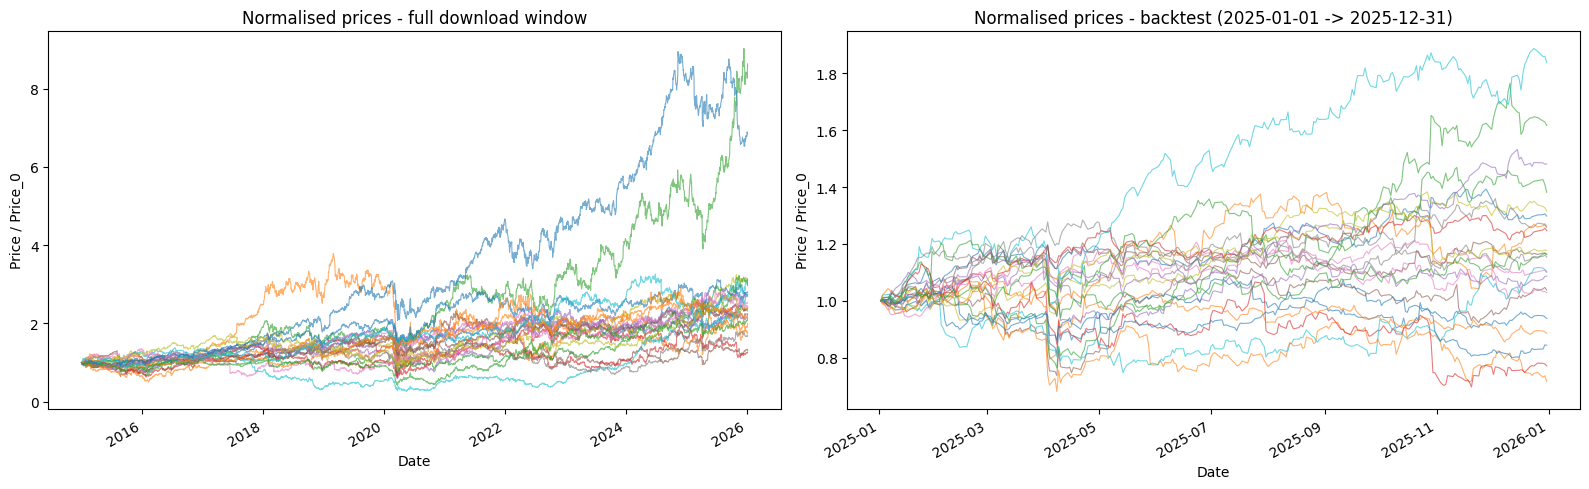


> Backtest period: 250 trading days
> Total downloaded: 2767 trading days


In [65]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

norm = prices_df / prices_df.iloc[0]
norm.plot(ax=axes[0], legend=False, alpha=0.6, lw=0.8)
axes[0].set_title('Normalised prices - full download window')
axes[0].set_ylabel('Price / Price_0')

bt_mask = (prices_df.index >= CFG.BT_START) & (prices_df.index <= CFG.BT_END)
bt_prices = prices_df.loc[bt_mask]
norm_bt = bt_prices / bt_prices.iloc[0]
norm_bt.plot(ax=axes[1], legend=False, alpha=0.6, lw=0.8)
axes[1].set_title(f'Normalised prices - backtest ({CFG.BT_START} -> {CFG.BT_END})')
axes[1].set_ylabel('Price / Price_0')

plt.tight_layout()
plt.show()

print(f'\n> Backtest period: {bt_prices.shape[0]} trading days')
print(f'> Total downloaded: {prices_df.shape[0]} trading days')

---
## <font color=#0099CC>**5. FFD WEIGHTS — computation & cross-check**</font>

In [66]:
import numpy as np
from frac_diff_utils import ffd_weights, ffd_apply

weights = ffd_weights(CFG.D_FRAC, CFG.FFD_THRESHOLD)
L = len(weights)

print(f'-- FFD weights (d={CFG.D_FRAC}, threshold={CFG.FFD_THRESHOLD}) --')
print(f'  L (retained weights) : {L}')
print(f'  w[0]                 : {weights[0]:.6f}  (should be 1.0)')
print(f'  w[1]                 : {weights[1]:.6f}  (should be -{CFG.D_FRAC:.2f})')
print(f'  w[-1]                : {weights[-1]:.8f}')

try:
    from dataset_utils import calcular_pesos
    w_ref = calcular_pesos(CFG.D_FRAC, CFG.FFD_THRESHOLD)
    if hasattr(w_ref, 'values'):
        w_ref = w_ref.values.flatten()
    else:
        w_ref = np.array(w_ref).flatten()
    if len(w_ref) == L and np.allclose(weights, w_ref, atol=1e-12):
        print(f'\n\u2713 Cross-check PASSED: weights match calcular_pesos.')
    else:
        print(f'\n\u2717 Cross-check FAILED')
except ImportError:
    print('\nWarning: calcular_pesos not available.')

-- FFD weights (d=0.4, threshold=1e-05) --
  L (retained weights) : 1458
  w[0]                 : 1.000000  (should be 1.0)
  w[1]                 : -0.400000  (should be -0.40)
  w[-1]                : -0.00001001

✓ Cross-check PASSED: weights match calcular_pesos.


---
## <font color=#0099CC>**6. FRAC-DIFF SERIES**</font>

> log_prices shape : (2767, 23)
> Frac-diff valid  : 1310  (dropped 1457 = L-1)

-- Frac-diff stats (last 252 days) --
  Mean : 0.192267
  Std  : 0.024850
  Min  : -0.063350
  Max  : 0.401564


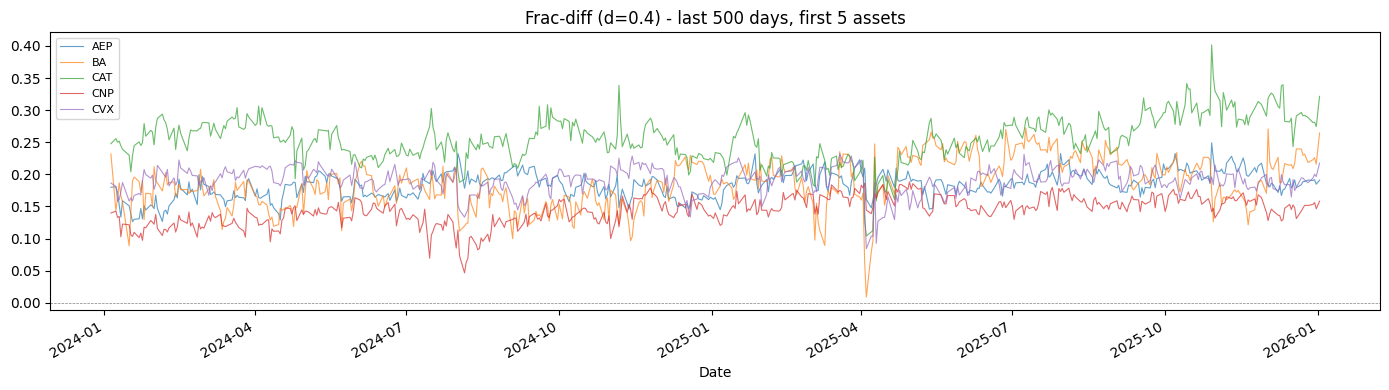

In [67]:
log_prices = prepare_log_prices(prices_df)

fd_values = ffd_apply(log_prices.values, d=CFG.D_FRAC, threshold=CFG.FFD_THRESHOLD)
fd_df = pd.DataFrame(fd_values, index=log_prices.index, columns=log_prices.columns)
fd_valid = fd_df.dropna()

print(f'> log_prices shape : {log_prices.shape}')
print(f'> Frac-diff valid  : {fd_valid.shape[0]}  (dropped {fd_df.shape[0] - fd_valid.shape[0]} = L-1)')

recent = fd_valid.tail(252)
print(f'\n-- Frac-diff stats (last 252 days) --')
print(f'  Mean : {recent.mean().mean():.6f}')
print(f'  Std  : {recent.std().mean():.6f}')
print(f'  Min  : {recent.min().min():.6f}')
print(f'  Max  : {recent.max().max():.6f}')

fig, ax = plt.subplots(figsize=(14, 4))
fd_valid[CFG.TICKERS[:5]].tail(500).plot(ax=ax, alpha=0.7, lw=0.8)
ax.set_title(f'Frac-diff (d={CFG.D_FRAC}) - last 500 days, first 5 assets')
ax.axhline(0, color='gray', ls='--', lw=0.5)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

---
## <font color=#0099CC>**7. MODEL — build & load via model_builder**</font>

Uses `model_builder.py` which auto-selects the correct architecture
(CNN, MLP, RNN, or Mixto) based on `CFG.ARCH`.

**Requires TensorFlow** — skip this cell on local Windows if TF is broken.

In [68]:
import tensorflow as tf
print(f'> TensorFlow : {tf.__version__}')
print(f'> GPU        : {tf.config.list_physical_devices("GPU")}\n')

import model_builder
importlib.reload(model_builder)
from model_builder import build_and_load_model

model = build_and_load_model(CFG, BASE)
model.summary()

> TensorFlow : 2.20.0
> GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

> Model     : inv_cnn (cnn, v_in=10, v_out=90)
> Checkpoint: inv_cnn_vin10_vout90_best.weights.h5
> Parameters: 39,703


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 10, 64)         │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 10, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 10, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 10, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,703 (155.09 KB)

 Trainable params: 39,319 (153.59 KB)

 Non-trainable params: 384 (1.50 KB)

### Sanity-check prediction

In [69]:
dummy_input = np.random.randn(1, CFG.V_IN, CFG.N_ASSETS).astype(np.float32)
dummy_output = model.predict(dummy_input, verbose=0)

print(f'> Input shape  : {dummy_input.shape}')
print(f'> Output shape : {dummy_output.shape}  (expected: (1, {CFG.N_ASSETS}))')
print(f'> Output range : [{dummy_output.min():.6f}, {dummy_output.max():.6f}]')

assert dummy_output.shape == (1, CFG.N_ASSETS), 'Output shape mismatch!'
print('\n\u2713 Forward pass OK.')

> Input shape  : (1, 10, 23)
> Output shape : (1, 23)  (expected: (1, 23))
> Output range : [-0.011279, 0.110110]

✓ Forward pass OK.


---
## <font color=#0099CC>**8. SCALER — reconstruct from training data**</font>

In [70]:
from sklearn.preprocessing import StandardScaler

scaler = None

# Method 1 (preferred): exact training scaler via dataset_utils
try:
    from dataset_utils import (
        load_data, create_dataset, get_partitions_temporal,
        D_FRAC_INV, RANDOM_STATE_VAL,
    )
    data_train, df_train = load_data(d_frac=D_FRAC_INV, verbose=True)
    X_all, Y_all = create_dataset(data_train, CFG.V_IN, CFG.V_OUT, verbose=True)
    _, _, _, _, _, _, scaler = get_partitions_temporal(
        X_all, Y_all, v_in=CFG.V_IN, v_out=CFG.V_OUT,
        scaler=CFG.SCALER, return_scaler=True,
        random_state=RANDOM_STATE_VAL, verbose=True,
    )
    print(f'\n\u2713 Exact training scaler reconstructed.')
except ImportError as e:
    print(f'Warning: dataset_utils not available ({e}). Using fallback.')

# Method 2 (fallback): fit on pre-backtest frac-diff
if scaler is None:
    pre_bt_mask = fd_valid.index < pd.Timestamp(CFG.BT_START)
    fd_pre_bt = fd_valid.loc[pre_bt_mask]
    scaler = StandardScaler()
    scaler.fit(fd_pre_bt.values)
    print(f'Warning: Using fallback scaler fit on {fd_pre_bt.shape[0]:,} pre-backtest days.')

print(f'\n> Scaler type   : {type(scaler).__name__}')
print(f'> Scaler means  : {scaler.mean_[:5].round(6)} ...')
print(f'> Scaler scales : {scaler.scale_[:5].round(6)} ...')

> Descargando datos desde 1945-01-01 hasta hoy...


[*********************100%***********************]  23 of 23 completed


> Frac-diff aplicada — d=0.4, L=1458 pesos, 1457 filas iniciales descartadas (~8.99% del histórico).
> Shape resultante: (14746, 23)
> Dataset creado — X: (14647, 10, 23), Y: (14647, 23)
> Scaler: standard fitted on X_tr only — applied to train/val/test
> Split temporal con embargo  (v_in=10, v_out=90, embargo=100)
  Train   [     0,  11517)  ->   11517 muestras
  Val     [ 11617,  13082)  ->    1465 muestras  (gap previo: 100)
  Test    [ 13182,  14647)  ->    1465 muestras  (gap previo: 100)
  Descartadas por embargo: 200 muestras  (1.37% del total)

✓ Exact training scaler reconstructed.

> Scaler type   : StandardScaler
> Scaler means  : [0.062904 0.078939 0.075525 0.031486 0.069575] ...
> Scaler scales : [0.054119 0.087925 0.063352 0.061237 0.066451] ...


---
## <font color=#0099CC>**9. FFD INVERSION — predicted frac-diff -> expected returns**</font>

Full inference at the **first rebalancing date**.

In [71]:
from frac_diff_utils import ffd_invert_expected_return

trading_dates = get_trading_dates(prices_df, CFG.BT_START, CFG.BT_END)
rebal_dates = compute_rebalancing_dates(trading_dates, CFG.REBAL_DAYS)

print(f'> Trading days : {len(trading_dates)}')
print(f'> Rebalancing  : {len(rebal_dates)}')
for i, d in enumerate(rebal_dates):
    print(f'    [{i}] {d.date()}')

# Test on first rebalancing date
rebal_date = rebal_dates[0]
print(f'\n== Inference at {rebal_date.date()} ==')

# Step 1: V_IN-day frac-diff window
fd_up_to = fd_valid.loc[:rebal_date]
window_fd = fd_up_to.iloc[-CFG.V_IN:].values
print(f'  Window shape: {window_fd.shape}  (expected: ({CFG.V_IN}, {CFG.N_ASSETS}))')

# Step 2: Scale
window_scaled = scaler.transform(window_fd)

# Step 3: Predict
X_input = window_scaled[np.newaxis, ...]
pred_avg_fd = model.predict(X_input, verbose=0).squeeze()

# Step 4: FFD inversion
lp_up_to = log_prices.loc[:rebal_date].values
exp_ret = ffd_invert_expected_return(
    pred_avg_fracdiff=pred_avg_fd,
    log_prices_history=lp_up_to,
    weights=weights,
    horizon=CFG.V_OUT,
)

print(f'\n  Expected returns (over {CFG.V_OUT} trading days):')
ranking = np.argsort(exp_ret)[::-1]
for rank, idx in enumerate(ranking):
    marker = ' << TOP-K' if rank < CFG.TOP_K and exp_ret[idx] > 0 else ''
    print(f'    #{rank+1:2d}  {CFG.TICKERS[idx]:>5s} : {exp_ret[idx]:+.4%}{marker}')

> Trading days : 250
> Rebalancing  : 3
    [0] 2025-01-02
    [1] 2025-05-14
    [2] 2025-09-23

== Inference at 2025-01-02 ==
  Window shape: (10, 23)  (expected: (10, 23))

  Expected returns (over 90 trading days):
    # 1     KO : +13.5676% << TOP-K
    # 2    JNJ : +11.1544% << TOP-K
    # 3     BA : +3.7840% << TOP-K
    # 4    MRK : +2.6598% << TOP-K
    # 5    CVX : +2.5957% << TOP-K
    # 6    XOM : -0.1194%
    # 7    DIS : -1.5915%
    # 8     PG : -2.1140%
    # 9     GE : -3.4212%
    #10     ED : -4.7391%
    #11     MO : -5.8566%
    #12    CNP : -6.5035%
    #13    HPQ : -7.5213%
    #14    MMM : -9.8103%
    #15    AEP : -10.8283%
    #16    DTE : -12.7394%
    #17     GD : -13.1148%
    #18     IP : -15.4755%
    #19    IBM : -17.9458%
    #20     KR : -18.8049%
    #21    HON : -20.8174%
    #22    CAT : -26.5825%
    #23    MSI : -37.9056%


---
## <font color=#0099CC>**10. SANITY CHECK — expected vs actual returns**</font>

In [72]:
rebal_idx = list(trading_dates).index(rebal_date)
end_idx = min(rebal_idx + CFG.V_OUT, len(trading_dates) - 1)
end_date = trading_dates[end_idx]

price_start = prices_df.loc[rebal_date].values
price_end   = prices_df.loc[end_date].values
actual_ret = (price_end / price_start) - 1

print(f'Period: {rebal_date.date()} -> {end_date.date()} ({end_idx - rebal_idx} trading days)\n')
print(f'{"Asset":>6s}  {"Expected":>10s}  {"Actual":>10s}  {"Diff":>10s}')
print('-' * 42)
for i in ranking:
    diff = exp_ret[i] - actual_ret[i]
    print(f'{CFG.TICKERS[i]:>6s}  {exp_ret[i]:>+10.4%}  {actual_ret[i]:>+10.4%}  {diff:>+10.4%}')

from scipy.stats import spearmanr
corr, pval = spearmanr(exp_ret, actual_ret)
print(f'\n> Spearman rank correlation: {corr:.4f}  (p={pval:.4f})')
if corr > 0.3:
    print('  -> Positive ranking signal.')
elif corr > 0:
    print('  -> Weak positive signal.')
else:
    print('  -> Negative or zero signal.')

Period: 2025-01-02 -> 2025-05-14 (90 trading days)

 Asset    Expected      Actual        Diff
------------------------------------------
    KO   +13.5676%   +12.6623%    +0.9053%
   JNJ   +11.1544%    +2.4382%    +8.7161%
    BA    +3.7840%   +19.1133%   -15.3293%
   MRK    +2.6598%   -25.2751%   +27.9348%
   CVX    +2.5957%    -2.3643%    +4.9599%
   XOM    -0.1194%    +1.9945%    -2.1140%
   DIS    -1.5915%    +1.9130%    -3.5045%
    PG    -2.1140%    -3.6182%    +1.5042%
    GE    -3.4212%   +32.6623%   -36.0835%
    ED    -4.7391%   +13.4592%   -18.1983%
    MO    -5.8566%    +9.2070%   -15.0636%
   CNP    -6.5035%   +16.8864%   -23.3900%
   HPQ    -7.5213%   -10.8646%    +3.3434%
   MMM    -9.8103%   +14.5794%   -24.3897%
   AEP   -10.8283%    +9.2015%   -20.0298%
   DTE   -12.7394%   +10.4881%   -23.2276%
    GD   -13.1148%    +4.8379%   -17.9528%
    IP   -15.4755%    -4.5469%   -10.9286%
   IBM   -17.9458%   +18.7891%   -36.7349%
    KR   -18.8049%    +7.6284%   -26.4333%
  

---
## <font color=#0099CC>**11. DIAGNOSTIC SUMMARY**</font>

If all cells ran without errors, the pipeline is verified.

**Next step**: run `02_inference_colab.ipynb` to generate
`expected_returns_{model}.csv`, then `03_backtest.ipynb`.